In [ ]:

from google.colab import drive
import os


drive.mount('/content/drive')
print(" Google Drive Connected!")

ZIP_PATH = "/content/drive/MyDrive/Music_Project/archive.zip"
#colab extract
os.makedirs('/content/dataset', exist_ok=True)
!unzip -q "{ZIP_PATH}" -d "/content/dataset/"
print(" ZIP File Extracted Successfully in Colab!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Google Drive Connected!
replace /content/dataset/Data/features_30_sec.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename:  ZIP File Extracted Successfully in Colab!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Extracting Audio Features with Overlap...
Processing Genre: hiphop...
Processing Genre: blues...
Processing Genre: classical...
Processing Genre: rock...
Processing Genre: metal...
Processing Genre: disco...
Processing Genre: pop...
Processing Genre: jazz...


/tmp/ipykernel_1111/2195099091.py:39: UserWarning: PySoundFile failed. Trying audioread instead.
  aud, sr = librosa.load(file_path, sr=target_sr, duration=30.0)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processing Genre: reggae...
Processing Genre: country...

Total Images Created: 18400

Building 4-Layer CNN Architecture...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Starting Training Session...
Epoch 1/80
460/460 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.3408 - loss: 1.7837 - val_accuracy: 0.4437 - val_loss: 1.5416 - learning_rate: 5.0000e-04
Epoch 2/80
460/460 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.5607 - loss: 1.2373 - val_accuracy: 0.6079 - val_loss: 1.1576 - learning_rate: 5.0000e-04
Epoch 3/80
460/460 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.6346 - loss: 1.0471 - val_accuracy: 0.7095 - val_loss: 0.8987 - learning_rate: 5.0000e-04
Epoch 4/80
460/460 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.6895 - loss: 0.8865 - val_accuracy: 0.7372 - val_loss: 0.7583 - learning_rate: 5.0000e-04
Epoch 5/80
460/460 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7381 - loss: 0.7607 - val_accuracy: 0.7745 - val_loss: 0.6775 - learning_rate: 5.0000e-04
Epoch 6/80
460/460 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7698 - loss: 0.6694 - val_accuracy: 0.8011 - val_loss: 0.5873 - learning_rate: 5.0000e-04
Epoch 7/80
460/460 ━━━


Model and Labels saved.

Generating Confusion Matrix...
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


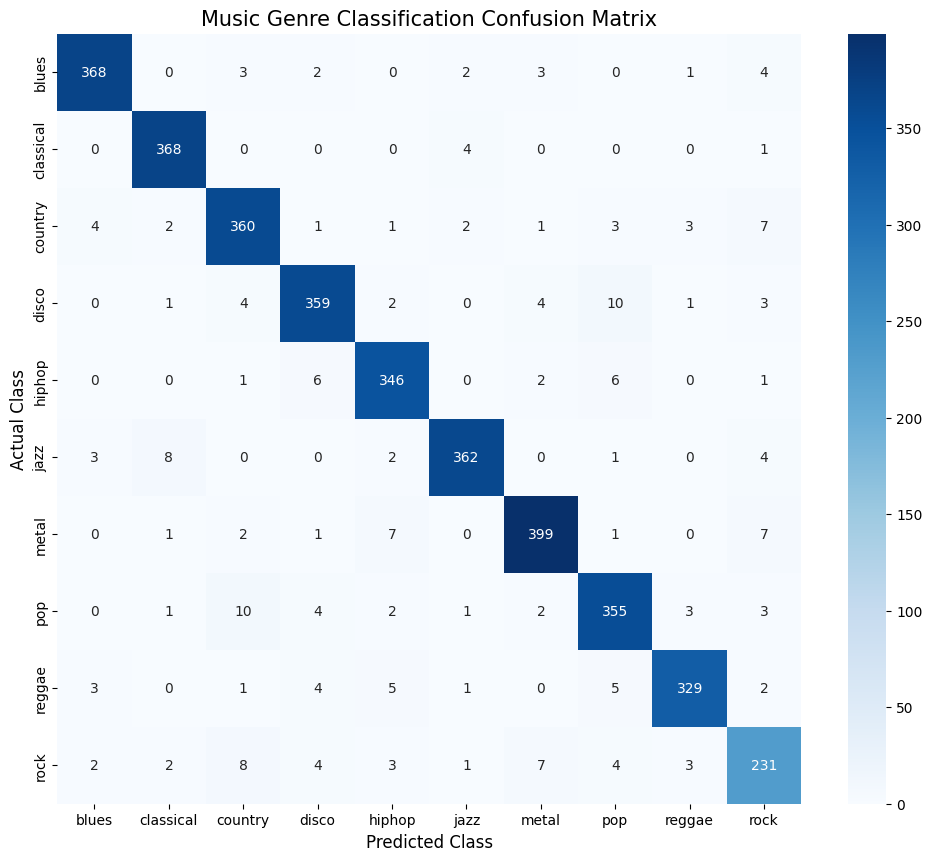

In [ ]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pickle

dataset_path = "/content/dataset/Data/genres_original"
genres = os.listdir(dataset_path)

X = []
y = []

print("Extracting Audio Features with Overlap...")

chunk_sec = 3.0
overlap_sec = 1.5
target_sr = 22050

chunk_samp = int(chunk_sec * target_sr)
step_samp = int((chunk_sec - overlap_sec) * target_sr)

for genre in genres:
    genre_path = os.path.join(dataset_path, genre)
    if not os.path.isdir(genre_path): continue

    print(f"Processing Genre: {genre}...")
    for file in os.listdir(genre_path):
        if file.endswith('.wav'):
            file_path = os.path.join(genre_path, file)
            try:
                aud, sr = librosa.load(file_path, sr=target_sr, duration=30.0)

                for st in range(0, len(aud) - chunk_samp + 1, step_samp):
                    en = st + chunk_samp
                    chk = aud[st:en]

                    if len(chk) < chunk_samp: continue

                    sp = librosa.feature.melspectrogram(y=chk, sr=sr, n_mels=128)
                    ls = librosa.power_to_db(sp, ref=np.max)

                    if ls.shape[1] < 128:
                        ls = np.pad(ls, ((0, 0), (0, 128 - ls.shape[1])))
                    else:
                        ls = ls[:, :128]

                    mn = np.min(ls)
                    mx = np.max(ls)
                    ls = (ls - mn) / (mx - mn + 1e-6)

                    X.append(ls.reshape(128, 128, 1))
                    y.append(genre)
            except Exception as e:
                pass

X = np.array(X)
y = np.array(y)

print(f"\nTotal Images Created: {X.shape[0]}")

enc = LabelEncoder()
y_enc = enc.fit_transform(y)
pickle.dump(enc, open("g.pkl", "wb"))

X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42)

print("\nBuilding 4-Layer CNN Architecture...")

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(10, activation='softmax')
])

custom_adam = Adam(learning_rate=0.0005)
model.compile(optimizer=custom_adam, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=0.00001, verbose=1)

print("\nStarting Training Session...")

history = model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[es, rlr]
)

model.save("b.h5")
print("\nModel and Labels saved.")

print("\nGenerating Confusion Matrix...")
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=enc.classes_, yticklabels=enc.classes_)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('Actual Class', fontsize=12)
plt.title('Music Genre Classification Confusion Matrix', fontsize=15)
plt.show()

In [ ]:
import os
import numpy as np
import librosa
import pickle
from tensorflow.keras.models import load_model
from google.colab import files


try:
    m = load_model("b.h5")
    enc = pickle.load(open("g.pkl", "rb"))
except Exception as e:
    print("❌ ERROR:")
    exit()


def test_smart_overlap(f_path):
    try:

        aud, sr = librosa.load(f_path, offset=15.0, duration=30.0, mono=True, sr=22050)


        chunk_sec = 3.0
        overlap_sec = 1.5

        chunk_samp = int(chunk_sec * sr)
        step_samp = int((chunk_sec - overlap_sec) * sr)

        chunks = []


        for st in range(0, len(aud) - chunk_samp + 1, step_samp):
            en = st + chunk_samp
            chk = aud[st:en]


            sp = librosa.feature.melspectrogram(y=chk, sr=sr, n_mels=128)
            ls = librosa.power_to_db(sp, ref=np.max)


            if ls.shape[1] < 128:
                ls = np.pad(ls, ((0, 0), (0, 128 - ls.shape[1])))
            else:
                ls = ls[:, :128]


            mn = np.min(ls)
            mx = np.max(ls)
            ls = (ls - mn) / (mx - mn + 1e-6)

            chunks.append(ls.reshape(128, 128, 1))

        if len(chunks) == 0: return "ERROR", 0


        chunks = np.array(chunks)
        pr = m.predict(chunks, verbose=0)


        avg_pr = np.mean(pr, axis=0)
        final_idx = np.argmax(avg_pr)
        final_genre = enc.inverse_transform([final_idx])[0].upper()
        confidence = avg_pr[final_idx] * 100

        return final_genre, confidence

    except Exception as e:
        print(f"Processing Error: {e}")
        return "ERROR", 0


print("👇 Apna naya gaana (.mp3/.wav) upload karein:")
uploaded = files.upload()

if len(uploaded) > 0:
    test_file = list(uploaded.keys())[0]

    print("\n" + "🚀" * 15)
    print(f"🎵 Analyzing Audio Track: {test_file}")
    print("🚀" * 15)

    pred_genre, conf = test_smart_overlap(test_file)

    if pred_genre != "ERROR":
        print(f"\n   🎯 FINAL VERDICT: {pred_genre} ")
        print(f"   📊 CONFIDENCE SCORE: {conf:.2f}%\n")
    else:
        print("\n❌ Error processing the song.")
else:
    print("\nNO file uploaded")

👇 Apna naya gaana (.mp3/.wav) upload karein:


Saving 2pac – Dear Mama.mp3 to 2pac – Dear Mama (1).mp3

🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀
🎵 Analyzing Audio Track: 2pac – Dear Mama (1).mp3
🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀

   🎯 FINAL VERDICT: HIPHOP 
   📊 CONFIDENCE SCORE: 39.43%

